# Analyse Helios Simulations
This notebook walks through the process of analysing helios simulations which follows 3 main steps:

    (1) Data Preparation
        This stage will setup the project directory, setup expected schemas for dataframes (both dask and pandas), and ultimately read in the helios data and prepare the required per ray information into a .parquet output.
        It will also setup the reference dataset for voxels for each voxel_size in the project (i.e. unique voxel_ids etc.).
    
    (2) Voxel-Ray Intersection
        With valid rays saved per leg of the scan, in the previous step, the goal now is to check ray intersections in all voxels. This will record important information, such as the entry/exit/hit coordinates of the ray which will later be used to gather metrics.
        The main reason these metrics are not gathered yet, is that this stage will remain separate per leg. That way, the metrics can be computed from different combinations of helios legs without re-computing voxel-ray intersections.

    (3) Compute Metrics
        Taking a given set of legs and voxel_sizes, the voxel_ray intersection files will be used to calculate metrics for each voxel, in this case resulting in all outputs from each investigated method.

# Step 1 - Setup Project
Set project paths here

In [1]:
import os

# Set up the project directory
project_dir = '/home/capheus/projects/AMAPVox_test/POTR2_uniform/tls_sim_POTR2_uniform'
helios_dir = os.path.join(project_dir, 'helios')
references_dir = os.path.join(project_dir, 'references')
results_dir = os.path.join(project_dir, 'results')
valid_rays_dir = os.path.join(project_dir, 'valid_rays')

if not os.path.exists(helios_dir) or not os.path.exists(references_dir):
    raise FileNotFoundError("The specified directories do not exist. Please check the paths.")

if not os.path.exists(valid_rays_dir):
    os.makedirs(valid_rays_dir, exist_ok=True)

if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)

use_class = True
leaf_object_ids = [1]
wood_object_ids = [0]


## Step 1 - Data Preparation
This step focuses on converting helios simulation outputs, saving only valid rays into a more efficient .parquet file format.

It expects the following input and will add a new folder (valid_rays) to store all resulting .parquet files.

INPUT:
    project_dir/
    ├── reference/
    │   ├── "{project}_voxel_size_0.2.csv"
    │   ├── "{project}_voxel_size_0.5.csv"
    │   ...
    │   └── "{project}_voxel_size_{v}.csv"
    ├── helios/
    │   ├── "leg000_points.xyz"
    │   ├── "leg000_pulse.txt"
    │   ├── "leg000_fullwave.txt"
    │   ├── "leg001_points.xyz"
    │   ├── "leg001_pulse.txt"
    │   ├── "leg001_fullwave.txt"
    │   ├── ...
    │   ├── "leg{l}_points.xyz"
    │   ├── "leg{l}_pulse.txt"
    │   └── "leg{l}_fullwave.txt"

OUTPUT:
    └── valid_rays/
        ├── "leg_000_valid_rays.parquet"
        ├── "leg_001_valid_rays.parquet"
        ...
        └── "leg_{l}_valid_rays.parquet"

Processing dask delayed functions...

[                                        ] | 0% Completed | 241.01 us


[                                        ] | 0% Completed | 102.54 ms


[########################################] | 100% Completed | 209.11 ms

Processing leg 0...

[                                        ] | 0% Completed | 107.34 us


[##                                      ] | 5% Completed | 105.85 ms

...


[########################################] | 100% Completed | 1.33 s

Debugging output...


Total Helios points 302711 do not match total valid points 302608


Total Helios rays 80956593 match total valid rays 80956593


Plotting leaf and wood points to check classification...


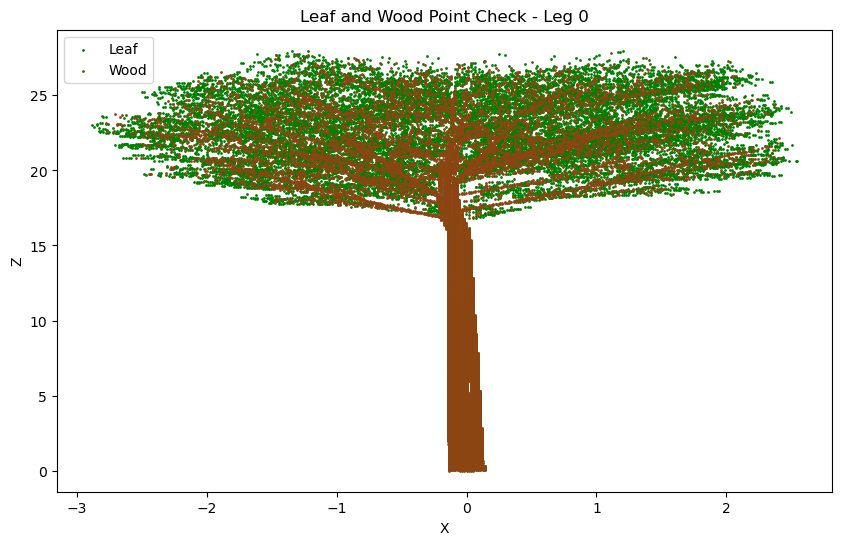

Saving leaf and wood point clouds...
Helios data preparation complete.


<Figure size 640x480 with 0 Axes>

In [2]:
from utils import prepare_helios_data

# Run the data preparation script
prepare_helios_data(
    input_dir=helios_dir, 
    output_dir=valid_rays_dir, 
    references_dir=references_dir, 
    leaf_object_ids=leaf_object_ids, 
    wood_object_ids=wood_object_ids, 
    use_class=use_class,
    debug=True
)

### Step 1.5 -  Compute Normals and Weights for Leaf Points

In [3]:
from utils import add_normals_weights_to_valid_rays

# Calculate normals and weights by loading valid rays
add_normals_weights_to_valid_rays(
    valid_rays_dir, 
    debug=True,
    knn=6
)

Loading 12 files...

[                                        ] | 0% Completed | 212.61 us


[                                        ] | 0% Completed | 105.38 ms


[                                        ] | 0% Completed | 215.40 ms


[                                        ] | 0% Completed | 316.22 ms


[                                        ] | 0% Completed | 417.49 ms

...

Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_uniform/valid_rays/leg_7_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_uniform/valid_rays/leg_8_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_uniform/valid_rays/leg_9_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_uniform/valid_rays/leg_10_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_uniform/valid_rays/leg_11_valid_rays.parquet
Saved 12 valid rays files with normals and weights.


## Step 2 - Voxel Ray Intersections
This code uses the valid rays from before, alongside the reference datasets in order to create a supporting parquet in the valid rays folder using the voxel_size_{voxel_size}_leg_{leg}_intersections.parquet format.

In [4]:
from utils import voxel_ray_intersections

# Run intersections
voxel_ray_intersections(
    valid_rays_dir=valid_rays_dir, 
    references_dir=references_dir,
    debug=False
)

[voxel_ray_intersections] Initialising Dask client...
Detected SLURM_CPUS_PER_TASK=96
Using HPC temporary directory: /scratch/temp/19786452
[voxel_ray_intersections] Starting Dask with memory_limit=12500MB


Found 4 voxel reference files.


Compiled voxel references with 19136 entries.
Found 12 valid rays files.
[voxel_ray_intersections] Loading valid rays file for leg 0: /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_uniform/valid_rays/leg_0_valid_rays.parquet
[voxel_ray_intersections] Leg 0 partitions: 6
[voxel_ray_intersections] Mapped partitions for leg 0
[voxel_ray_intersections] Loading valid rays file for leg 3: /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_uniform/valid_rays/leg_3_valid_rays.parquet
[voxel_ray_intersections] Leg 3 partitions: 6
[voxel_ray_intersections] Mapped partitions for leg 3
[voxel_ray_intersections] Loading valid rays file for leg 2: /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_uniform/valid_rays/leg_2_valid_rays.parquet
[voxel_ray_intersections] Leg 2 partitions: 6
[voxel_ray_intersections] Mapped partitions for leg 2
[voxel_ray_intersections] Loading valid rays file for leg 1: /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/P

[voxel_ray_intersections] Leg 7 grouped into 4 voxel_size groups.
[voxel_ray_intersections] Saving group voxel_size=0.2 (rows=354050) for leg 7


Saved intersections for leg_id: 7 to /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_uniform/valid_rays/leg_7_voxel_0.2_intersections.parquet.
[voxel_ray_intersections] Saving group voxel_size=0.5 (rows=328274) for leg 7


...

2026-01-16 12:30:56,327 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:39637' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-88dc6eadccbb74b891714395b05d6309', 0)} (stimulus_id='handle-worker-cleanup-1768530656.3277998')


2026-01-16 12:30:56,331 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:34859' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-d18cbf9330d9788c48d5696f61a20f0a', 0)} (stimulus_id='handle-worker-cleanup-1768530656.331231')


[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1503488
  - Optimal chunk size: 55 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[

[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels


Deleted Dask worker scratch space at /scratch/temp/19786452/dask-scratch-space
[voxel_ray_intersections] Dask client closed.


## Step 3 - Compute Metrics
Using the leg_{leg_id}_voxel_size_{voxel_size}_intersections.parquet files (which feature a standardised structure of columns from various inputs), compute the desired metrics and save outputs.

In [5]:
import os
import glob
import utils
import pandas as pd
from utils import calculate_lambda_1, get_voxel_metrics

# Select the desired legs and voxel_sizes to include in the analysis
# Use the shortcut string 'all' to include all 
legs = 'all' # [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] 
voxel_sizes = 'all' #'all' # [0.2, 0.5, 1.0, 2.0]

leg_string = None if not legs == 'all' else legs

# Set the average leaf area
average_leaf_area = 0.0018803000643493  # in m^2, adjust as needed

# Get the list of all voxel sizes
intersection_files = []
if legs == 'all' and voxel_sizes == 'all':
    intersection_files = glob.glob(os.path.join(valid_rays_dir, '*_intersections.parquet'))
elif legs == 'all' and isinstance(voxel_sizes, list):
    for voxel_size in voxel_sizes:
        intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_*_voxel_{voxel_size}_intersections.parquet'))
elif isinstance(legs, list) and voxel_sizes == 'all':
    for leg in legs:
        intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_{leg}_*_intersections.parquet'))
else:
    for leg in legs:
        for voxel_size in voxel_sizes:
            intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_{leg}_voxel_{voxel_size}_intersections.parquet'))

# Check if any intersection files were found
if intersection_files == []:
    print("No intersection files found. Please check the input parameters.")

# Split intersection files into separate lists for each voxel_size
voxel_size_files = {}
for file in intersection_files:
    # Extract the voxel size from the filename
    parts = file.split('_')
    voxel_size = float(parts[parts.index('voxel') + 1])
    
    # Add the file to the corresponding voxel size list
    if voxel_size not in voxel_size_files:
        voxel_size_files[voxel_size] = []
    voxel_size_files[voxel_size].append(file)

# Extract voxel information for each voxel size
for voxel_size, files in voxel_size_files.items():
    # Create a list of all legs in files
    legs = []
    for file in files:
        leg = os.path.basename(file)
        parts = leg.split('_')
        leg = int(parts[parts.index('leg') + 1])
        legs.append(leg)

    # Calculate the lambda_1 for average leaf area
    lambda_1 = calculate_lambda_1(voxel_size=voxel_size, average_leaf_area=average_leaf_area)
    print(f"Voxel size: {voxel_size}, Lambda_1: {lambda_1}")

    # Calculate per voxel information from all files
    voxel_metrics_df = get_voxel_metrics(
        intersections_files=files, 
        lambda_1=lambda_1,
        is_multireturn=False
    )

    # Retrieve the reference file
    reference_file = glob.glob(os.path.join(references_dir, f'*{voxel_size}*'))[0]
    df_ref = pd.read_csv(reference_file)

    # CI_leaf_Corr, CI_lw_Corr
    # Ensure only numeric columns are included in the mean operation
    if 'voxel_id' in df_ref.columns:
        df_ref = df_ref.groupby('voxel_id').mean(numeric_only=True).reset_index()
        df_ref = df_ref.add_suffix('_ref')
    elif 'voxel_cx' in df_ref.columns:
        df_ref = df_ref.groupby(['voxel_cx', 'voxel_cy', 'voxel_cz']).mean(numeric_only=True).reset_index()
        df_ref = df_ref.add_suffix('_ref')

    df_ref.rename(columns={
        'voxel_id_ref': 'voxel_id',
        'LAD_ref_ref': 'LAD_ref', 
        'PAD_ref_ref': 'PAD_ref'
        }, inplace=True)

    for c in ['voxel_cx' ,'voxel_cy', 'voxel_cz']:
        if c + '_ref' in df_ref.columns:
            df_ref.rename(columns={c + '_ref': c}, inplace=True)

    # Merge to maintain voxel_id matching
    if 'voxel_id' in df_ref.columns:
        voxel_metrics_df = voxel_metrics_df.merge(df_ref, on='voxel_id', how='left')

        if 'voxel_cx' in voxel_metrics_df.columns:
            voxel_metrics_df.drop(columns=['voxel_cx'], inplace=True)
        if 'voxel_cy' in voxel_metrics_df.columns:
            voxel_metrics_df.drop(columns=['voxel_cy'], inplace=True)
        if 'voxel_cz' in voxel_metrics_df.columns:
            voxel_metrics_df.drop(columns=['voxel_cz'], inplace=True)
            
    elif 'voxel_cx' in df_ref.columns:
        voxel_metrics_df = voxel_metrics_df.merge(df_ref, on=['voxel_cx', 'voxel_cy', 'voxel_cz'], how='left')
    

    ### Add LAD calculations here if desired
    """Example, LAD_BL_TLS

    # Retrieve required variables
    I_leaf = voxel_metrics_df['I_leaf'].values
    mean_path_length = voxel_metrics_df['mean_path_length'].values  
    G_leaf = voxel_metrics_df['G_leaf'].values
    CI_leaf_ref = voxel_metrics_df['CI_leaf_corr_ref'].values

    LAD_BL_TLS = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length)
    LAD_BL_TLS_G = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length, G=G_leaf)
    LAD_BL_TLS_CI_ref = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length, G=G_leaf, CI=CI_leaf_ref)
    """

    # Save outputs to csv
    project_name = os.path.basename(os.path.normpath(project_dir))
    if leg_string is None:
        legs.sort()
        leg_string = "_".join(map(str, legs))
    output_file = os.path.join(results_dir, f"{project_name}_leg_{leg_string}_voxel_size_{voxel_size}.csv")
    if os.path.exists(output_file):
        os.remove(output_file)
    voxel_metrics_df.to_csv(output_file)

Voxel size: 2.0, Lambda_1: 0.0002350375080436625


2026-01-16 12:31:01,759 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 33dcbb98c2b06d897574f00a23f9ebbc initialized by task ('shuffle-transfer-33dcbb98c2b06d897574f00a23f9ebbc', 3) executed on worker tcp://127.0.0.1:39071


2026-01-16 12:31:03,945 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 33dcbb98c2b06d897574f00a23f9ebbc deactivated due to stimulus 'task-finished-1768530663.940438'


2026-01-16 12:31:05,017 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:38087' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-9961cb33ec642f686364667de4e047d8', 0)} (stimulus_id='handle-worker-cleanup-1768530665.0169542')


Deleted Dask worker scratch space at /scratch/temp/19786452/dask-scratch-space
Voxel size: 1.0, Lambda_1: 0.0018803000643493


...

2026-01-16 12:31:29,682 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 34831a3478d3137221e74ad534d94dee initialized by task ('shuffle-transfer-34831a3478d3137221e74ad534d94dee', 9) executed on worker tcp://127.0.0.1:33865


2026-01-16 12:31:31,810 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 34831a3478d3137221e74ad534d94dee deactivated due to stimulus 'task-finished-1768530691.8077765'


2026-01-16 12:31:46,054 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/home/uqrarya1/miniconda3/envs/plantdensityanalysis_env/lib/python3.13/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/uqrarya1/miniconda3/envs/plantdensityanalysis_env/lib/python3.13/site-packages/distributed/worker.py", line 1267, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
    ...<14 lines>...
    )
    ^
  File "/home/uqrarya1/miniconda3/envs/plantdensityanalysis_env/lib/python3.13/site-packages/distributed/utils_comm.py", line 416, in retry_operation
    return await retry(
   

Voxel 2023936964 has no rays.


Deleted Dask worker scratch space at /scratch/temp/19786452/dask-scratch-space


# Analyse Helios Simulations
This notebook walks through the process of analysing helios simulations which follows 3 main steps:

    (1) Data Preparation
        This stage will setup the project directory, setup expected schemas for dataframes (both dask and pandas), and ultimately read in the helios data and prepare the required per ray information into a .parquet output.
        It will also setup the reference dataset for voxels for each voxel_size in the project (i.e. unique voxel_ids etc.).
    
    (2) Voxel-Ray Intersection
        With valid rays saved per leg of the scan, in the previous step, the goal now is to check ray intersections in all voxels. This will record important information, such as the entry/exit/hit coordinates of the ray which will later be used to gather metrics.
        The main reason these metrics are not gathered yet, is that this stage will remain separate per leg. That way, the metrics can be computed from different combinations of helios legs without re-computing voxel-ray intersections.

    (3) Compute Metrics
        Taking a given set of legs and voxel_sizes, the voxel_ray intersection files will be used to calculate metrics for each voxel, in this case resulting in all outputs from each investigated method.

# Step 1 - Setup Project
Set project paths here

In [6]:
import os

# Set up the project directory
project_dir = '/scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_spherical'
helios_dir = os.path.join(project_dir, 'helios')
references_dir = os.path.join(project_dir, 'references')
results_dir = os.path.join(project_dir, 'results')
valid_rays_dir = os.path.join(project_dir, 'valid_rays')

if not os.path.exists(helios_dir) or not os.path.exists(references_dir):
    raise FileNotFoundError("The specified directories do not exist. Please check the paths.")

if not os.path.exists(valid_rays_dir):
    os.makedirs(valid_rays_dir, exist_ok=True)

if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)

use_class = True
leaf_object_ids = [1]
wood_object_ids = [0]


## Step 1 - Data Preparation
This step focuses on converting helios simulation outputs, saving only valid rays into a more efficient .parquet file format.

It expects the following input and will add a new folder (valid_rays) to store all resulting .parquet files.

INPUT:
    project_dir/
    ├── reference/
    │   ├── "{project}_voxel_size_0.2.csv"
    │   ├── "{project}_voxel_size_0.5.csv"
    │   ...
    │   └── "{project}_voxel_size_{v}.csv"
    ├── helios/
    │   ├── "leg000_points.xyz"
    │   ├── "leg000_pulse.txt"
    │   ├── "leg000_fullwave.txt"
    │   ├── "leg001_points.xyz"
    │   ├── "leg001_pulse.txt"
    │   ├── "leg001_fullwave.txt"
    │   ├── ...
    │   ├── "leg{l}_points.xyz"
    │   ├── "leg{l}_pulse.txt"
    │   └── "leg{l}_fullwave.txt"

OUTPUT:
    └── valid_rays/
        ├── "leg_000_valid_rays.parquet"
        ├── "leg_001_valid_rays.parquet"
        ...
        └── "leg_{l}_valid_rays.parquet"

Processing dask delayed functions...

[                                        ] | 0% Completed | 199.16 us


[###                                     ] | 8% Completed | 103.49 ms


[########################################] | 100% Completed | 221.43 ms

Processing leg 0...

[                                        ] | 0% Completed | 125.44 us


[##                                      ] | 5% Completed | 103.85 ms

...


[####################################    ] | 91% Completed | 1.03 s


[######################################  ] | 97% Completed | 1.13 s


[########################################] | 100% Completed | 1.23 s

Debugging output...
Total Helios points 301634 do not match total valid points 301549


Total Helios rays 80956627 match total valid rays 80956627
Plotting leaf and wood points to check classification...


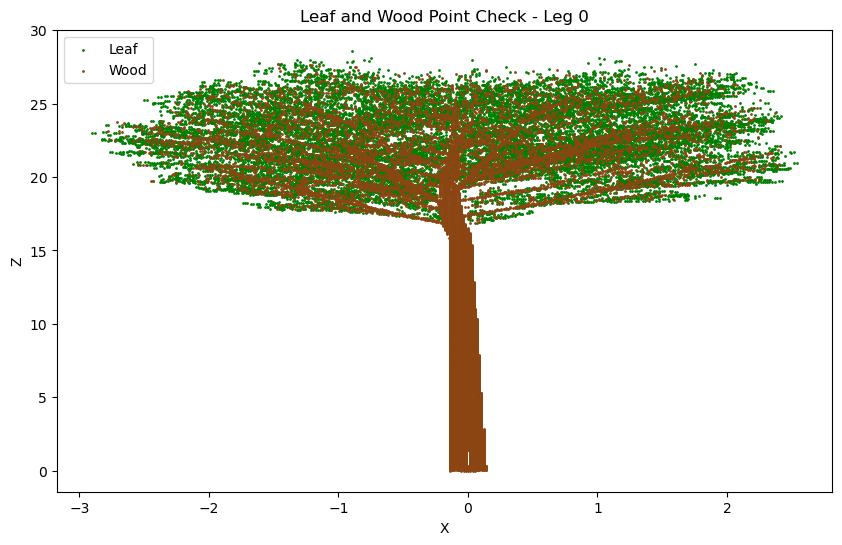

Saving leaf and wood point clouds...
Helios data preparation complete.


<Figure size 640x480 with 0 Axes>

In [7]:
from utils import prepare_helios_data

# Run the data preparation script
prepare_helios_data(
    input_dir=helios_dir, 
    output_dir=valid_rays_dir, 
    references_dir=references_dir, 
    leaf_object_ids=leaf_object_ids, 
    wood_object_ids=wood_object_ids, 
    use_class=use_class,
    debug=True
)

### Step 1.5 -  Compute Normals and Weights for Leaf Points

In [8]:
from utils import add_normals_weights_to_valid_rays

# Calculate normals and weights by loading valid rays
add_normals_weights_to_valid_rays(
    valid_rays_dir, 
    debug=True,
    knn=6
)

Loading 12 files...

[                                        ] | 0% Completed | 424.50 us


[                                        ] | 0% Completed | 102.07 ms


[                                        ] | 0% Completed | 203.97 ms


[                                        ] | 0% Completed | 305.13 ms


[                                        ] | 0% Completed | 405.96 ms

...

Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_spherical/valid_rays/leg_7_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_spherical/valid_rays/leg_8_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_spherical/valid_rays/leg_9_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_spherical/valid_rays/leg_10_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_spherical/valid_rays/leg_11_valid_rays.parquet
Saved 12 valid rays files with normals and weights.


## Step 2 - Voxel Ray Intersections
This code uses the valid rays from before, alongside the reference datasets in order to create a supporting parquet in the valid rays folder using the voxel_size_{voxel_size}_leg_{leg}_intersections.parquet format.

In [9]:
from utils import voxel_ray_intersections

# Run intersections
voxel_ray_intersections(
    valid_rays_dir=valid_rays_dir, 
    references_dir=references_dir,
    debug=False
)

[voxel_ray_intersections] Initialising Dask client...
Detected SLURM_CPUS_PER_TASK=96
Using HPC temporary directory: /scratch/temp/19786452
[voxel_ray_intersections] Starting Dask with memory_limit=12500MB


Found 4 voxel reference files.


Compiled voxel references with 19066 entries.
Found 12 valid rays files.
[voxel_ray_intersections] Loading valid rays file for leg 0: /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_spherical/valid_rays/leg_0_valid_rays.parquet
[voxel_ray_intersections] Leg 0 partitions: 6
[voxel_ray_intersections] Mapped partitions for leg 0
[voxel_ray_intersections] Loading valid rays file for leg 3: /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_spherical/valid_rays/leg_3_valid_rays.parquet
[voxel_ray_intersections] Leg 3 partitions: 6
[voxel_ray_intersections] Mapped partitions for leg 3
[voxel_ray_intersections] Loading valid rays file for leg 2: /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_spherical/valid_rays/leg_2_valid_rays.parquet
[voxel_ray_intersections] Leg 2 partitions: 6
[voxel_ray_intersections] Mapped partitions for leg 2
[voxel_ray_intersections] Loading valid rays file for leg 1: /scratch/project/veg3d/uqrarya1/code/PlantDensityAnal

[voxel_ray_intersections] Leg 10 grouped into 4 voxel_size groups.
[voxel_ray_intersections] Saving group voxel_size=0.2 (rows=415558) for leg 10


Saved intersections for leg_id: 10 to /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_spherical/valid_rays/leg_10_voxel_0.2_intersections.parquet.
[voxel_ray_intersections] Saving group voxel_size=0.5 (rows=375574) for leg 10
Saved intersections for leg_id: 10 to /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_spherical/valid_rays/leg_10_voxel_0.5_intersections.parquet.
[voxel_ray_intersections] Saving group voxel_size=1.0 (rows=298211) for leg 10


...

2026-01-16 13:30:47,869 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:43239' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-b620a4d53f799f209b4bdcd44a8b546f', 0)} (stimulus_id='handle-worker-cleanup-1768534247.8690836')


2026-01-16 13:30:47,874 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:36397' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-0e9c2e58513d64e423524e6ff0e00b4d', 0)} (stimulus_id='handle-worker-cleanup-1768534247.8741257')


2026-01-16 13:30:47,884 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:44407' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-5d08b663a3cbce77c172f66f5e173d6c', 0)} (stimulus_id='handle-worker-cleanup-1768534247.8846524')


[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1503488
  - Optimal chunk size: 55 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[

Deleted Dask worker scratch space at /scratch/temp/19786452/dask-scratch-space
[voxel_ray_intersections] Dask client closed.


## Step 3 - Compute Metrics
Using the leg_{leg_id}_voxel_size_{voxel_size}_intersections.parquet files (which feature a standardised structure of columns from various inputs), compute the desired metrics and save outputs.

In [10]:
import os
import glob
import utils
import pandas as pd
from utils import calculate_lambda_1, get_voxel_metrics

# Select the desired legs and voxel_sizes to include in the analysis
# Use the shortcut string 'all' to include all 
legs = 'all' # [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] 
voxel_sizes = 'all' #'all' # [0.2, 0.5, 1.0, 2.0]

leg_string = None if not legs == 'all' else legs

# Set the average leaf area
average_leaf_area = 0.0018803000643493  # in m^2, adjust as needed

# Get the list of all voxel sizes
intersection_files = []
if legs == 'all' and voxel_sizes == 'all':
    intersection_files = glob.glob(os.path.join(valid_rays_dir, '*_intersections.parquet'))
elif legs == 'all' and isinstance(voxel_sizes, list):
    for voxel_size in voxel_sizes:
        intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_*_voxel_{voxel_size}_intersections.parquet'))
elif isinstance(legs, list) and voxel_sizes == 'all':
    for leg in legs:
        intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_{leg}_*_intersections.parquet'))
else:
    for leg in legs:
        for voxel_size in voxel_sizes:
            intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_{leg}_voxel_{voxel_size}_intersections.parquet'))

# Check if any intersection files were found
if intersection_files == []:
    print("No intersection files found. Please check the input parameters.")

# Split intersection files into separate lists for each voxel_size
voxel_size_files = {}
for file in intersection_files:
    # Extract the voxel size from the filename
    parts = file.split('_')
    voxel_size = float(parts[parts.index('voxel') + 1])
    
    # Add the file to the corresponding voxel size list
    if voxel_size not in voxel_size_files:
        voxel_size_files[voxel_size] = []
    voxel_size_files[voxel_size].append(file)

# Extract voxel information for each voxel size
for voxel_size, files in voxel_size_files.items():
    # Create a list of all legs in files
    legs = []
    for file in files:
        leg = os.path.basename(file)
        parts = leg.split('_')
        leg = int(parts[parts.index('leg') + 1])
        legs.append(leg)

    # Calculate the lambda_1 for average leaf area
    lambda_1 = calculate_lambda_1(voxel_size=voxel_size, average_leaf_area=average_leaf_area)
    print(f"Voxel size: {voxel_size}, Lambda_1: {lambda_1}")

    # Calculate per voxel information from all files
    voxel_metrics_df = get_voxel_metrics(
        intersections_files=files, 
        lambda_1=lambda_1,
        is_multireturn=False
    )

    # Retrieve the reference file
    reference_file = glob.glob(os.path.join(references_dir, f'*{voxel_size}*'))[0]
    df_ref = pd.read_csv(reference_file)

    # CI_leaf_Corr, CI_lw_Corr
    # Ensure only numeric columns are included in the mean operation
    if 'voxel_id' in df_ref.columns:
        df_ref = df_ref.groupby('voxel_id').mean(numeric_only=True).reset_index()
        df_ref = df_ref.add_suffix('_ref')
    elif 'voxel_cx' in df_ref.columns:
        df_ref = df_ref.groupby(['voxel_cx', 'voxel_cy', 'voxel_cz']).mean(numeric_only=True).reset_index()
        df_ref = df_ref.add_suffix('_ref')

    df_ref.rename(columns={
        'voxel_id_ref': 'voxel_id',
        'LAD_ref_ref': 'LAD_ref', 
        'PAD_ref_ref': 'PAD_ref'
        }, inplace=True)

    for c in ['voxel_cx' ,'voxel_cy', 'voxel_cz']:
        if c + '_ref' in df_ref.columns:
            df_ref.rename(columns={c + '_ref': c}, inplace=True)

    # Merge to maintain voxel_id matching
    if 'voxel_id' in df_ref.columns:
        voxel_metrics_df = voxel_metrics_df.merge(df_ref, on='voxel_id', how='left')

        if 'voxel_cx' in voxel_metrics_df.columns:
            voxel_metrics_df.drop(columns=['voxel_cx'], inplace=True)
        if 'voxel_cy' in voxel_metrics_df.columns:
            voxel_metrics_df.drop(columns=['voxel_cy'], inplace=True)
        if 'voxel_cz' in voxel_metrics_df.columns:
            voxel_metrics_df.drop(columns=['voxel_cz'], inplace=True)
            
    elif 'voxel_cx' in df_ref.columns:
        voxel_metrics_df = voxel_metrics_df.merge(df_ref, on=['voxel_cx', 'voxel_cy', 'voxel_cz'], how='left')
    

    ### Add LAD calculations here if desired
    """Example, LAD_BL_TLS

    # Retrieve required variables
    I_leaf = voxel_metrics_df['I_leaf'].values
    mean_path_length = voxel_metrics_df['mean_path_length'].values  
    G_leaf = voxel_metrics_df['G_leaf'].values
    CI_leaf_ref = voxel_metrics_df['CI_leaf_corr_ref'].values

    LAD_BL_TLS = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length)
    LAD_BL_TLS_G = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length, G=G_leaf)
    LAD_BL_TLS_CI_ref = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length, G=G_leaf, CI=CI_leaf_ref)
    """

    # Save outputs to csv
    project_name = os.path.basename(os.path.normpath(project_dir))
    if leg_string is None:
        legs.sort()
        leg_string = "_".join(map(str, legs))
    output_file = os.path.join(results_dir, f"{project_name}_leg_{leg_string}_voxel_size_{voxel_size}.csv")
    if os.path.exists(output_file):
        os.remove(output_file)
    voxel_metrics_df.to_csv(output_file)

Voxel size: 2.0, Lambda_1: 0.0002350375080436625


2026-01-16 13:30:53,757 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 3c7db52c5d853301f33b6e06f9d4a52c initialized by task ('shuffle-transfer-3c7db52c5d853301f33b6e06f9d4a52c', 11) executed on worker tcp://127.0.0.1:36927


2026-01-16 13:30:56,383 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 3c7db52c5d853301f33b6e06f9d4a52c deactivated due to stimulus 'task-finished-1768534256.3796434'


2026-01-16 13:30:57,581 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:39307' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-e7e777e27f3505117cc3ee69be9c0e77', 0)} (stimulus_id='handle-worker-cleanup-1768534257.5815902')


Deleted Dask worker scratch space at /scratch/temp/19786452/dask-scratch-space
Voxel size: 1.0, Lambda_1: 0.0018803000643493


...

Voxel size: 0.2, Lambda_1: 0.23503750804366247


2026-01-16 13:31:22,127 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 43a2d6554cd4bd965794a6959b9e4a8b initialized by task ('shuffle-transfer-43a2d6554cd4bd965794a6959b9e4a8b', 0) executed on worker tcp://127.0.0.1:39769


2026-01-16 13:31:24,296 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 43a2d6554cd4bd965794a6959b9e4a8b deactivated due to stimulus 'task-finished-1768534284.294346'


2026-01-16 13:31:37,282 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:43885' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-9353c1a25fc8b22d03339dace139e048', 0)} (stimulus_id='handle-worker-cleanup-1768534297.2820785')


Deleted Dask worker scratch space at /scratch/temp/19786452/dask-scratch-space


# Analyse Helios Simulations
This notebook walks through the process of analysing helios simulations which follows 3 main steps:

    (1) Data Preparation
        This stage will setup the project directory, setup expected schemas for dataframes (both dask and pandas), and ultimately read in the helios data and prepare the required per ray information into a .parquet output.
        It will also setup the reference dataset for voxels for each voxel_size in the project (i.e. unique voxel_ids etc.).
    
    (2) Voxel-Ray Intersection
        With valid rays saved per leg of the scan, in the previous step, the goal now is to check ray intersections in all voxels. This will record important information, such as the entry/exit/hit coordinates of the ray which will later be used to gather metrics.
        The main reason these metrics are not gathered yet, is that this stage will remain separate per leg. That way, the metrics can be computed from different combinations of helios legs without re-computing voxel-ray intersections.

    (3) Compute Metrics
        Taking a given set of legs and voxel_sizes, the voxel_ray intersection files will be used to calculate metrics for each voxel, in this case resulting in all outputs from each investigated method.

# Step 1 - Setup Project
Set project paths here

In [11]:
import os

# Set up the project directory
project_dir = '/scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_planophile'
helios_dir = os.path.join(project_dir, 'helios')
references_dir = os.path.join(project_dir, 'references')
results_dir = os.path.join(project_dir, 'results')
valid_rays_dir = os.path.join(project_dir, 'valid_rays')

if not os.path.exists(helios_dir) or not os.path.exists(references_dir):
    raise FileNotFoundError("The specified directories do not exist. Please check the paths.")

if not os.path.exists(valid_rays_dir):
    os.makedirs(valid_rays_dir, exist_ok=True)

if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)

use_class = True
leaf_object_ids = [1]
wood_object_ids = [0]


## Step 1 - Data Preparation
This step focuses on converting helios simulation outputs, saving only valid rays into a more efficient .parquet file format.

It expects the following input and will add a new folder (valid_rays) to store all resulting .parquet files.

INPUT:
    project_dir/
    ├── reference/
    │   ├── "{project}_voxel_size_0.2.csv"
    │   ├── "{project}_voxel_size_0.5.csv"
    │   ...
    │   └── "{project}_voxel_size_{v}.csv"
    ├── helios/
    │   ├── "leg000_points.xyz"
    │   ├── "leg000_pulse.txt"
    │   ├── "leg000_fullwave.txt"
    │   ├── "leg001_points.xyz"
    │   ├── "leg001_pulse.txt"
    │   ├── "leg001_fullwave.txt"
    │   ├── ...
    │   ├── "leg{l}_points.xyz"
    │   ├── "leg{l}_pulse.txt"
    │   └── "leg{l}_fullwave.txt"

OUTPUT:
    └── valid_rays/
        ├── "leg_000_valid_rays.parquet"
        ├── "leg_001_valid_rays.parquet"
        ...
        └── "leg_{l}_valid_rays.parquet"

Processing dask delayed functions...

[                                        ] | 0% Completed | 216.31 us


[                                        ] | 0% Completed | 101.48 ms


[################                        ] | 41% Completed | 205.01 ms


[########################################] | 100% Completed | 317.47 ms

Processing leg 0...

[                                        ] | 0% Completed | 115.66 us

...


[#####################################   ] | 94% Completed | 1.03 s


[######################################  ] | 97% Completed | 1.13 s


[########################################] | 100% Completed | 1.23 s

Debugging output...
Total Helios points 304456 do not match total valid points 304364


Total Helios rays 80956654 match total valid rays 80956654
Plotting leaf and wood points to check classification...


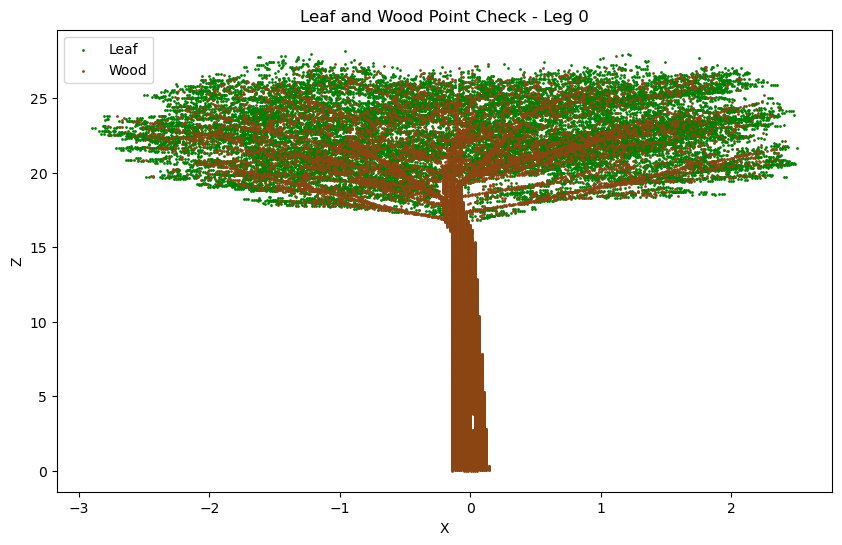

Saving leaf and wood point clouds...
Helios data preparation complete.


<Figure size 640x480 with 0 Axes>

In [12]:
from utils import prepare_helios_data

# Run the data preparation script
prepare_helios_data(
    input_dir=helios_dir, 
    output_dir=valid_rays_dir, 
    references_dir=references_dir, 
    leaf_object_ids=leaf_object_ids, 
    wood_object_ids=wood_object_ids, 
    use_class=use_class,
    debug=True
)

### Step 1.5 -  Compute Normals and Weights for Leaf Points

In [13]:
from utils import add_normals_weights_to_valid_rays

# Calculate normals and weights by loading valid rays
add_normals_weights_to_valid_rays(
    valid_rays_dir, 
    debug=True,
    knn=6
)

Loading 12 files...

[                                        ] | 0% Completed | 185.69 us


[                                        ] | 0% Completed | 104.90 ms


[                                        ] | 0% Completed | 223.19 ms


[                                        ] | 0% Completed | 323.84 ms


[                                        ] | 0% Completed | 424.53 ms

...

Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_planophile/valid_rays/leg_7_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_planophile/valid_rays/leg_8_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_planophile/valid_rays/leg_9_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_planophile/valid_rays/leg_10_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_planophile/valid_rays/leg_11_valid_rays.parquet
Saved 12 valid rays files with normals and weights.


## Step 2 - Voxel Ray Intersections
This code uses the valid rays from before, alongside the reference datasets in order to create a supporting parquet in the valid rays folder using the voxel_size_{voxel_size}_leg_{leg}_intersections.parquet format.

In [14]:
from utils import voxel_ray_intersections

# Run intersections
voxel_ray_intersections(
    valid_rays_dir=valid_rays_dir, 
    references_dir=references_dir,
    debug=False
)

[voxel_ray_intersections] Initialising Dask client...
Detected SLURM_CPUS_PER_TASK=96
Using HPC temporary directory: /scratch/temp/19786452
[voxel_ray_intersections] Starting Dask with memory_limit=12500MB


Found 4 voxel reference files.


Compiled voxel references with 19077 entries.
Found 12 valid rays files.
[voxel_ray_intersections] Loading valid rays file for leg 0: /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_planophile/valid_rays/leg_0_valid_rays.parquet
[voxel_ray_intersections] Leg 0 partitions: 6
[voxel_ray_intersections] Mapped partitions for leg 0
[voxel_ray_intersections] Loading valid rays file for leg 3: /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_planophile/valid_rays/leg_3_valid_rays.parquet
[voxel_ray_intersections] Leg 3 partitions: 6
[voxel_ray_intersections] Mapped partitions for leg 3
[voxel_ray_intersections] Loading valid rays file for leg 2: /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_planophile/valid_rays/leg_2_valid_rays.parquet
[voxel_ray_intersections] Leg 2 partitions: 6
[voxel_ray_intersections] Mapped partitions for leg 2
[voxel_ray_intersections] Loading valid rays file for leg 1: /scratch/project/veg3d/uqrarya1/code/PlantDensityA

[voxel_ray_intersections] Leg 10 grouped into 4 voxel_size groups.
[voxel_ray_intersections] Saving group voxel_size=0.2 (rows=415480) for leg 10


Saved intersections for leg_id: 10 to /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_planophile/valid_rays/leg_10_voxel_0.2_intersections.parquet.
[voxel_ray_intersections] Saving group voxel_size=0.5 (rows=374590) for leg 10
Saved intersections for leg_id: 10 to /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_planophile/valid_rays/leg_10_voxel_0.5_intersections.parquet.
[voxel_ray_intersections] Saving group voxel_size=1.0 (rows=296366) for leg 10


...

2026-01-16 14:33:58,473 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:34659' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-3f7f7d232bdff2a0569757f6911f2e0d', 0)} (stimulus_id='handle-worker-cleanup-1768538038.4732964')


2026-01-16 14:33:58,474 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:39483' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-50fc714d114181ea06e15b1726040df6', 0)} (stimulus_id='handle-worker-cleanup-1768538038.4741583')


[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1503488
  - Optimal chunk size: 55 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[

[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1503470
  - Optimal chunk size: 55 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1503744
  - Optimal chunk size: 55 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1503488
  - Optimal chunk size: 55 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[

Deleted Dask worker scratch space at /scratch/temp/19786452/dask-scratch-space
[voxel_ray_intersections] Dask client closed.


## Step 3 - Compute Metrics
Using the leg_{leg_id}_voxel_size_{voxel_size}_intersections.parquet files (which feature a standardised structure of columns from various inputs), compute the desired metrics and save outputs.

In [15]:
import os
import glob
import utils
import pandas as pd
from utils import calculate_lambda_1, get_voxel_metrics

# Select the desired legs and voxel_sizes to include in the analysis
# Use the shortcut string 'all' to include all 
legs = 'all' # [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] 
voxel_sizes = 'all' #'all' # [0.2, 0.5, 1.0, 2.0]

leg_string = None if not legs == 'all' else legs

# Set the average leaf area
average_leaf_area = 0.0018803000643493  # in m^2, adjust as needed

# Get the list of all voxel sizes
intersection_files = []
if legs == 'all' and voxel_sizes == 'all':
    intersection_files = glob.glob(os.path.join(valid_rays_dir, '*_intersections.parquet'))
elif legs == 'all' and isinstance(voxel_sizes, list):
    for voxel_size in voxel_sizes:
        intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_*_voxel_{voxel_size}_intersections.parquet'))
elif isinstance(legs, list) and voxel_sizes == 'all':
    for leg in legs:
        intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_{leg}_*_intersections.parquet'))
else:
    for leg in legs:
        for voxel_size in voxel_sizes:
            intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_{leg}_voxel_{voxel_size}_intersections.parquet'))

# Check if any intersection files were found
if intersection_files == []:
    print("No intersection files found. Please check the input parameters.")

# Split intersection files into separate lists for each voxel_size
voxel_size_files = {}
for file in intersection_files:
    # Extract the voxel size from the filename
    parts = file.split('_')
    voxel_size = float(parts[parts.index('voxel') + 1])
    
    # Add the file to the corresponding voxel size list
    if voxel_size not in voxel_size_files:
        voxel_size_files[voxel_size] = []
    voxel_size_files[voxel_size].append(file)

# Extract voxel information for each voxel size
for voxel_size, files in voxel_size_files.items():
    # Create a list of all legs in files
    legs = []
    for file in files:
        leg = os.path.basename(file)
        parts = leg.split('_')
        leg = int(parts[parts.index('leg') + 1])
        legs.append(leg)

    # Calculate the lambda_1 for average leaf area
    lambda_1 = calculate_lambda_1(voxel_size=voxel_size, average_leaf_area=average_leaf_area)
    print(f"Voxel size: {voxel_size}, Lambda_1: {lambda_1}")

    # Calculate per voxel information from all files
    voxel_metrics_df = get_voxel_metrics(
        intersections_files=files, 
        lambda_1=lambda_1,
        is_multireturn=False
    )

    # Retrieve the reference file
    reference_file = glob.glob(os.path.join(references_dir, f'*{voxel_size}*'))[0]
    df_ref = pd.read_csv(reference_file)

    # CI_leaf_Corr, CI_lw_Corr
    # Ensure only numeric columns are included in the mean operation
    if 'voxel_id' in df_ref.columns:
        df_ref = df_ref.groupby('voxel_id').mean(numeric_only=True).reset_index()
        df_ref = df_ref.add_suffix('_ref')
    elif 'voxel_cx' in df_ref.columns:
        df_ref = df_ref.groupby(['voxel_cx', 'voxel_cy', 'voxel_cz']).mean(numeric_only=True).reset_index()
        df_ref = df_ref.add_suffix('_ref')

    df_ref.rename(columns={
        'voxel_id_ref': 'voxel_id',
        'LAD_ref_ref': 'LAD_ref', 
        'PAD_ref_ref': 'PAD_ref'
        }, inplace=True)

    for c in ['voxel_cx' ,'voxel_cy', 'voxel_cz']:
        if c + '_ref' in df_ref.columns:
            df_ref.rename(columns={c + '_ref': c}, inplace=True)

    # Merge to maintain voxel_id matching
    if 'voxel_id' in df_ref.columns:
        voxel_metrics_df = voxel_metrics_df.merge(df_ref, on='voxel_id', how='left')

        if 'voxel_cx' in voxel_metrics_df.columns:
            voxel_metrics_df.drop(columns=['voxel_cx'], inplace=True)
        if 'voxel_cy' in voxel_metrics_df.columns:
            voxel_metrics_df.drop(columns=['voxel_cy'], inplace=True)
        if 'voxel_cz' in voxel_metrics_df.columns:
            voxel_metrics_df.drop(columns=['voxel_cz'], inplace=True)
            
    elif 'voxel_cx' in df_ref.columns:
        voxel_metrics_df = voxel_metrics_df.merge(df_ref, on=['voxel_cx', 'voxel_cy', 'voxel_cz'], how='left')
    

    ### Add LAD calculations here if desired
    """Example, LAD_BL_TLS

    # Retrieve required variables
    I_leaf = voxel_metrics_df['I_leaf'].values
    mean_path_length = voxel_metrics_df['mean_path_length'].values  
    G_leaf = voxel_metrics_df['G_leaf'].values
    CI_leaf_ref = voxel_metrics_df['CI_leaf_corr_ref'].values

    LAD_BL_TLS = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length)
    LAD_BL_TLS_G = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length, G=G_leaf)
    LAD_BL_TLS_CI_ref = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length, G=G_leaf, CI=CI_leaf_ref)
    """

    # Save outputs to csv
    project_name = os.path.basename(os.path.normpath(project_dir))
    if leg_string is None:
        legs.sort()
        leg_string = "_".join(map(str, legs))
    output_file = os.path.join(results_dir, f"{project_name}_leg_{leg_string}_voxel_size_{voxel_size}.csv")
    if os.path.exists(output_file):
        os.remove(output_file)
    voxel_metrics_df.to_csv(output_file)

Voxel size: 2.0, Lambda_1: 0.0002350375080436625


2026-01-16 14:34:04,729 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle c187d95ba4cc2f8021c3b301cf91983b initialized by task ('shuffle-transfer-c187d95ba4cc2f8021c3b301cf91983b', 9) executed on worker tcp://127.0.0.1:41159


2026-01-16 14:34:06,693 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle c187d95ba4cc2f8021c3b301cf91983b deactivated due to stimulus 'task-finished-1768538046.6884763'


2026-01-16 14:34:08,044 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:44105' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-1f5c8cb0e862670f98779dec4f710074', 0)} (stimulus_id='handle-worker-cleanup-1768538048.0447338')


Deleted Dask worker scratch space at /scratch/temp/19786452/dask-scratch-space
Voxel size: 1.0, Lambda_1: 0.0018803000643493


...

2026-01-16 14:34:32,717 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle bff6e8f19c285fcbb236119bfe4a1051 initialized by task ('shuffle-transfer-bff6e8f19c285fcbb236119bfe4a1051', 1) executed on worker tcp://127.0.0.1:40489


2026-01-16 14:34:34,390 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle bff6e8f19c285fcbb236119bfe4a1051 deactivated due to stimulus 'task-finished-1768538074.388413'


2026-01-16 14:34:46,432 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:37373' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-44e64d5d442d9239884c11c249f8b119', 0)} (stimulus_id='handle-worker-cleanup-1768538086.4323914')


Voxel 2434790949 has no rays.
Voxel 3449485002 has no rays.
Voxel 2310085937 has no rays.
Voxel 135181897 has no rays.
Voxel 1115362894 has no rays.


Deleted Dask worker scratch space at /scratch/temp/19786452/dask-scratch-space


# Analyse Helios Simulations
This notebook walks through the process of analysing helios simulations which follows 3 main steps:

    (1) Data Preparation
        This stage will setup the project directory, setup expected schemas for dataframes (both dask and pandas), and ultimately read in the helios data and prepare the required per ray information into a .parquet output.
        It will also setup the reference dataset for voxels for each voxel_size in the project (i.e. unique voxel_ids etc.).
    
    (2) Voxel-Ray Intersection
        With valid rays saved per leg of the scan, in the previous step, the goal now is to check ray intersections in all voxels. This will record important information, such as the entry/exit/hit coordinates of the ray which will later be used to gather metrics.
        The main reason these metrics are not gathered yet, is that this stage will remain separate per leg. That way, the metrics can be computed from different combinations of helios legs without re-computing voxel-ray intersections.

    (3) Compute Metrics
        Taking a given set of legs and voxel_sizes, the voxel_ray intersection files will be used to calculate metrics for each voxel, in this case resulting in all outputs from each investigated method.

# Step 1 - Setup Project
Set project paths here

In [16]:
import os

# Set up the project directory
project_dir = '/scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_plagiophile'
helios_dir = os.path.join(project_dir, 'helios')
references_dir = os.path.join(project_dir, 'references')
results_dir = os.path.join(project_dir, 'results')
valid_rays_dir = os.path.join(project_dir, 'valid_rays')

if not os.path.exists(helios_dir) or not os.path.exists(references_dir):
    raise FileNotFoundError("The specified directories do not exist. Please check the paths.")

if not os.path.exists(valid_rays_dir):
    os.makedirs(valid_rays_dir, exist_ok=True)

if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)

use_class = True
leaf_object_ids = [1]
wood_object_ids = [0]


## Step 1 - Data Preparation
This step focuses on converting helios simulation outputs, saving only valid rays into a more efficient .parquet file format.

It expects the following input and will add a new folder (valid_rays) to store all resulting .parquet files.

INPUT:
    project_dir/
    ├── reference/
    │   ├── "{project}_voxel_size_0.2.csv"
    │   ├── "{project}_voxel_size_0.5.csv"
    │   ...
    │   └── "{project}_voxel_size_{v}.csv"
    ├── helios/
    │   ├── "leg000_points.xyz"
    │   ├── "leg000_pulse.txt"
    │   ├── "leg000_fullwave.txt"
    │   ├── "leg001_points.xyz"
    │   ├── "leg001_pulse.txt"
    │   ├── "leg001_fullwave.txt"
    │   ├── ...
    │   ├── "leg{l}_points.xyz"
    │   ├── "leg{l}_pulse.txt"
    │   └── "leg{l}_fullwave.txt"

OUTPUT:
    └── valid_rays/
        ├── "leg_000_valid_rays.parquet"
        ├── "leg_001_valid_rays.parquet"
        ...
        └── "leg_{l}_valid_rays.parquet"

Processing dask delayed functions...

[                                        ] | 0% Completed | 282.54 us


[######                                  ] | 16% Completed | 102.78 ms


[########################################] | 100% Completed | 215.32 ms

Processing leg 0...

[                                        ] | 0% Completed | 291.06 us


[##                                      ] | 5% Completed | 109.00 ms

...


[######################################  ] | 97% Completed | 1.12 s


[######################################  ] | 97% Completed | 1.22 s


[########################################] | 100% Completed | 1.32 s

Debugging output...
Total Helios points 301008 do not match total valid points 300901


Total Helios rays 80956614 match total valid rays 80956614
Plotting leaf and wood points to check classification...


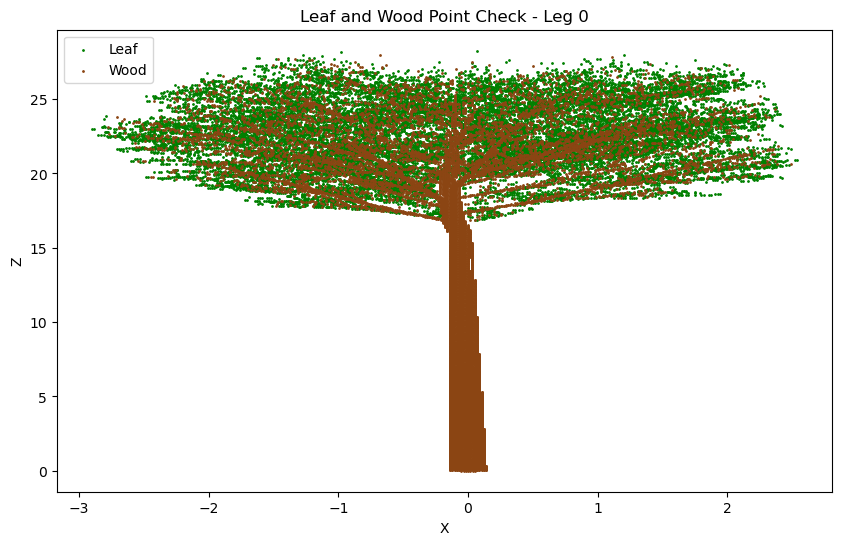

Saving leaf and wood point clouds...
Helios data preparation complete.


<Figure size 640x480 with 0 Axes>

In [17]:
from utils import prepare_helios_data

# Run the data preparation script
prepare_helios_data(
    input_dir=helios_dir, 
    output_dir=valid_rays_dir, 
    references_dir=references_dir, 
    leaf_object_ids=leaf_object_ids, 
    wood_object_ids=wood_object_ids, 
    use_class=use_class,
    debug=True
)

### Step 1.5 -  Compute Normals and Weights for Leaf Points

In [18]:
from utils import add_normals_weights_to_valid_rays

# Calculate normals and weights by loading valid rays
add_normals_weights_to_valid_rays(
    valid_rays_dir, 
    debug=True,
    knn=6
)

Loading 12 files...

[                                        ] | 0% Completed | 183.35 us


[                                        ] | 0% Completed | 102.88 ms


[                                        ] | 0% Completed | 203.76 ms


[                                        ] | 0% Completed | 304.70 ms


[                                        ] | 0% Completed | 405.46 ms

...

Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_plagiophile/valid_rays/leg_7_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_plagiophile/valid_rays/leg_8_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_plagiophile/valid_rays/leg_9_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_plagiophile/valid_rays/leg_10_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_plagiophile/valid_rays/leg_11_valid_rays.parquet
Saved 12 valid rays files with normals and weights.


## Step 2 - Voxel Ray Intersections
This code uses the valid rays from before, alongside the reference datasets in order to create a supporting parquet in the valid rays folder using the voxel_size_{voxel_size}_leg_{leg}_intersections.parquet format.

In [19]:
from utils import voxel_ray_intersections

# Run intersections
voxel_ray_intersections(
    valid_rays_dir=valid_rays_dir, 
    references_dir=references_dir,
    debug=False
)

[voxel_ray_intersections] Initialising Dask client...
Detected SLURM_CPUS_PER_TASK=96
Using HPC temporary directory: /scratch/temp/19786452
[voxel_ray_intersections] Starting Dask with memory_limit=12500MB


Found 4 voxel reference files.


Compiled voxel references with 19077 entries.
Found 12 valid rays files.
[voxel_ray_intersections] Loading valid rays file for leg 0: /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_plagiophile/valid_rays/leg_0_valid_rays.parquet
[voxel_ray_intersections] Leg 0 partitions: 6
[voxel_ray_intersections] Mapped partitions for leg 0
[voxel_ray_intersections] Loading valid rays file for leg 3: /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_plagiophile/valid_rays/leg_3_valid_rays.parquet
[voxel_ray_intersections] Leg 3 partitions: 6
[voxel_ray_intersections] Mapped partitions for leg 3
[voxel_ray_intersections] Loading valid rays file for leg 2: /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_plagiophile/valid_rays/leg_2_valid_rays.parquet
[voxel_ray_intersections] Leg 2 partitions: 6
[voxel_ray_intersections] Mapped partitions for leg 2
[voxel_ray_intersections] Loading valid rays file for leg 1: /scratch/project/veg3d/uqrarya1/code/PlantDensi

[voxel_ray_intersections] Leg 1 grouped into 4 voxel_size groups.


[voxel_ray_intersections] Saving group voxel_size=0.2 (rows=784589) for leg 1


...

2026-01-16 15:33:22,689 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:34873' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-f0cd2fac889332a29f6a4b4e61b7a9bd', 0)} (stimulus_id='handle-worker-cleanup-1768541602.6897514')


2026-01-16 15:33:22,692 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:40889' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-943e123b4e77c79ca801f10c0dfe7370', 0)} (stimulus_id='handle-worker-cleanup-1768541602.6922562')


2026-01-16 15:33:22,701 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:42661' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-dc9d8841a9532351bb9f84cf6a5a254b', 0)} (stimulus_id='handle-worker-cleanup-1768541602.7012646')


[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1503744
  - Optimal chunk size: 55 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1503488
  - Optimal chunk size: 55 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[

Deleted Dask worker scratch space at /scratch/temp/19786452/dask-scratch-space
[voxel_ray_intersections] Dask client closed.


## Step 3 - Compute Metrics
Using the leg_{leg_id}_voxel_size_{voxel_size}_intersections.parquet files (which feature a standardised structure of columns from various inputs), compute the desired metrics and save outputs.

In [20]:
import os
import glob
import utils
import pandas as pd
from utils import calculate_lambda_1, get_voxel_metrics

# Select the desired legs and voxel_sizes to include in the analysis
# Use the shortcut string 'all' to include all 
legs = 'all' # [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] 
voxel_sizes = 'all' #'all' # [0.2, 0.5, 1.0, 2.0]

leg_string = None if not legs == 'all' else legs

# Set the average leaf area
average_leaf_area = 0.0018803000643493  # in m^2, adjust as needed

# Get the list of all voxel sizes
intersection_files = []
if legs == 'all' and voxel_sizes == 'all':
    intersection_files = glob.glob(os.path.join(valid_rays_dir, '*_intersections.parquet'))
elif legs == 'all' and isinstance(voxel_sizes, list):
    for voxel_size in voxel_sizes:
        intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_*_voxel_{voxel_size}_intersections.parquet'))
elif isinstance(legs, list) and voxel_sizes == 'all':
    for leg in legs:
        intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_{leg}_*_intersections.parquet'))
else:
    for leg in legs:
        for voxel_size in voxel_sizes:
            intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_{leg}_voxel_{voxel_size}_intersections.parquet'))

# Check if any intersection files were found
if intersection_files == []:
    print("No intersection files found. Please check the input parameters.")

# Split intersection files into separate lists for each voxel_size
voxel_size_files = {}
for file in intersection_files:
    # Extract the voxel size from the filename
    parts = file.split('_')
    voxel_size = float(parts[parts.index('voxel') + 1])
    
    # Add the file to the corresponding voxel size list
    if voxel_size not in voxel_size_files:
        voxel_size_files[voxel_size] = []
    voxel_size_files[voxel_size].append(file)

# Extract voxel information for each voxel size
for voxel_size, files in voxel_size_files.items():
    # Create a list of all legs in files
    legs = []
    for file in files:
        leg = os.path.basename(file)
        parts = leg.split('_')
        leg = int(parts[parts.index('leg') + 1])
        legs.append(leg)

    # Calculate the lambda_1 for average leaf area
    lambda_1 = calculate_lambda_1(voxel_size=voxel_size, average_leaf_area=average_leaf_area)
    print(f"Voxel size: {voxel_size}, Lambda_1: {lambda_1}")

    # Calculate per voxel information from all files
    voxel_metrics_df = get_voxel_metrics(
        intersections_files=files, 
        lambda_1=lambda_1,
        is_multireturn=False
    )

    # Retrieve the reference file
    reference_file = glob.glob(os.path.join(references_dir, f'*{voxel_size}*'))[0]
    df_ref = pd.read_csv(reference_file)

    # CI_leaf_Corr, CI_lw_Corr
    # Ensure only numeric columns are included in the mean operation
    if 'voxel_id' in df_ref.columns:
        df_ref = df_ref.groupby('voxel_id').mean(numeric_only=True).reset_index()
        df_ref = df_ref.add_suffix('_ref')
    elif 'voxel_cx' in df_ref.columns:
        df_ref = df_ref.groupby(['voxel_cx', 'voxel_cy', 'voxel_cz']).mean(numeric_only=True).reset_index()
        df_ref = df_ref.add_suffix('_ref')

    df_ref.rename(columns={
        'voxel_id_ref': 'voxel_id',
        'LAD_ref_ref': 'LAD_ref', 
        'PAD_ref_ref': 'PAD_ref'
        }, inplace=True)

    for c in ['voxel_cx' ,'voxel_cy', 'voxel_cz']:
        if c + '_ref' in df_ref.columns:
            df_ref.rename(columns={c + '_ref': c}, inplace=True)

    # Merge to maintain voxel_id matching
    if 'voxel_id' in df_ref.columns:
        voxel_metrics_df = voxel_metrics_df.merge(df_ref, on='voxel_id', how='left')

        if 'voxel_cx' in voxel_metrics_df.columns:
            voxel_metrics_df.drop(columns=['voxel_cx'], inplace=True)
        if 'voxel_cy' in voxel_metrics_df.columns:
            voxel_metrics_df.drop(columns=['voxel_cy'], inplace=True)
        if 'voxel_cz' in voxel_metrics_df.columns:
            voxel_metrics_df.drop(columns=['voxel_cz'], inplace=True)
            
    elif 'voxel_cx' in df_ref.columns:
        voxel_metrics_df = voxel_metrics_df.merge(df_ref, on=['voxel_cx', 'voxel_cy', 'voxel_cz'], how='left')
    

    ### Add LAD calculations here if desired
    """Example, LAD_BL_TLS

    # Retrieve required variables
    I_leaf = voxel_metrics_df['I_leaf'].values
    mean_path_length = voxel_metrics_df['mean_path_length'].values  
    G_leaf = voxel_metrics_df['G_leaf'].values
    CI_leaf_ref = voxel_metrics_df['CI_leaf_corr_ref'].values

    LAD_BL_TLS = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length)
    LAD_BL_TLS_G = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length, G=G_leaf)
    LAD_BL_TLS_CI_ref = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length, G=G_leaf, CI=CI_leaf_ref)
    """

    # Save outputs to csv
    project_name = os.path.basename(os.path.normpath(project_dir))
    if leg_string is None:
        legs.sort()
        leg_string = "_".join(map(str, legs))
    output_file = os.path.join(results_dir, f"{project_name}_leg_{leg_string}_voxel_size_{voxel_size}.csv")
    if os.path.exists(output_file):
        os.remove(output_file)
    voxel_metrics_df.to_csv(output_file)

Voxel size: 2.0, Lambda_1: 0.0002350375080436625


2026-01-16 15:33:29,153 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 646b9130600426eb13458f8aaa3f4546 initialized by task ('shuffle-transfer-646b9130600426eb13458f8aaa3f4546', 3) executed on worker tcp://127.0.0.1:45769


2026-01-16 15:33:32,024 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 646b9130600426eb13458f8aaa3f4546 deactivated due to stimulus 'task-finished-1768541612.022555'


2026-01-16 15:33:32,930 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:45769' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-77b1967fc3df31c46aedcab67c523565', 0)} (stimulus_id='handle-worker-cleanup-1768541612.9308934')


Deleted Dask worker scratch space at /scratch/temp/19786452/dask-scratch-space
Voxel size: 1.0, Lambda_1: 0.0018803000643493


...

2026-01-16 15:33:58,896 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle ff76655d43b150207be10466e7a10d95 initialized by task ('shuffle-transfer-ff76655d43b150207be10466e7a10d95', 9) executed on worker tcp://127.0.0.1:41831


2026-01-16 15:34:00,856 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle ff76655d43b150207be10466e7a10d95 deactivated due to stimulus 'task-finished-1768541640.8433387'


2026-01-16 15:34:13,047 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:44093' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-d73f5e2cfd1e49b357f32c3e5253b72b', 0)} (stimulus_id='handle-worker-cleanup-1768541653.0473008')


Voxel 1878539443 has no rays.


Deleted Dask worker scratch space at /scratch/temp/19786452/dask-scratch-space


# Analyse Helios Simulations
This notebook walks through the process of analysing helios simulations which follows 3 main steps:

    (1) Data Preparation
        This stage will setup the project directory, setup expected schemas for dataframes (both dask and pandas), and ultimately read in the helios data and prepare the required per ray information into a .parquet output.
        It will also setup the reference dataset for voxels for each voxel_size in the project (i.e. unique voxel_ids etc.).
    
    (2) Voxel-Ray Intersection
        With valid rays saved per leg of the scan, in the previous step, the goal now is to check ray intersections in all voxels. This will record important information, such as the entry/exit/hit coordinates of the ray which will later be used to gather metrics.
        The main reason these metrics are not gathered yet, is that this stage will remain separate per leg. That way, the metrics can be computed from different combinations of helios legs without re-computing voxel-ray intersections.

    (3) Compute Metrics
        Taking a given set of legs and voxel_sizes, the voxel_ray intersection files will be used to calculate metrics for each voxel, in this case resulting in all outputs from each investigated method.

# Step 1 - Setup Project
Set project paths here

In [21]:
import os

# Set up the project directory
project_dir = '/scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_erectophile'
helios_dir = os.path.join(project_dir, 'helios')
references_dir = os.path.join(project_dir, 'references')
results_dir = os.path.join(project_dir, 'results')
valid_rays_dir = os.path.join(project_dir, 'valid_rays')

if not os.path.exists(helios_dir) or not os.path.exists(references_dir):
    raise FileNotFoundError("The specified directories do not exist. Please check the paths.")

if not os.path.exists(valid_rays_dir):
    os.makedirs(valid_rays_dir, exist_ok=True)

if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)

use_class = True
leaf_object_ids = [1]
wood_object_ids = [0]


## Step 1 - Data Preparation
This step focuses on converting helios simulation outputs, saving only valid rays into a more efficient .parquet file format.

It expects the following input and will add a new folder (valid_rays) to store all resulting .parquet files.

INPUT:
    project_dir/
    ├── reference/
    │   ├── "{project}_voxel_size_0.2.csv"
    │   ├── "{project}_voxel_size_0.5.csv"
    │   ...
    │   └── "{project}_voxel_size_{v}.csv"
    ├── helios/
    │   ├── "leg000_points.xyz"
    │   ├── "leg000_pulse.txt"
    │   ├── "leg000_fullwave.txt"
    │   ├── "leg001_points.xyz"
    │   ├── "leg001_pulse.txt"
    │   ├── "leg001_fullwave.txt"
    │   ├── ...
    │   ├── "leg{l}_points.xyz"
    │   ├── "leg{l}_pulse.txt"
    │   └── "leg{l}_fullwave.txt"

OUTPUT:
    └── valid_rays/
        ├── "leg_000_valid_rays.parquet"
        ├── "leg_001_valid_rays.parquet"
        ...
        └── "leg_{l}_valid_rays.parquet"

Processing dask delayed functions...

[                                        ] | 0% Completed | 555.65 us


[                                        ] | 0% Completed | 105.86 ms


[########################################] | 100% Completed | 222.12 ms

Processing leg 0...

[                                        ] | 0% Completed | 109.74 us


[##                                      ] | 5% Completed | 150.98 ms

...


[###################################     ] | 88% Completed | 973.73 ms


[######################################  ] | 97% Completed | 1.07 s


[########################################] | 100% Completed | 1.18 s

Debugging output...
Total Helios points 301224 do not match total valid points 301141


Total Helios rays 80956660 match total valid rays 80956660
Plotting leaf and wood points to check classification...


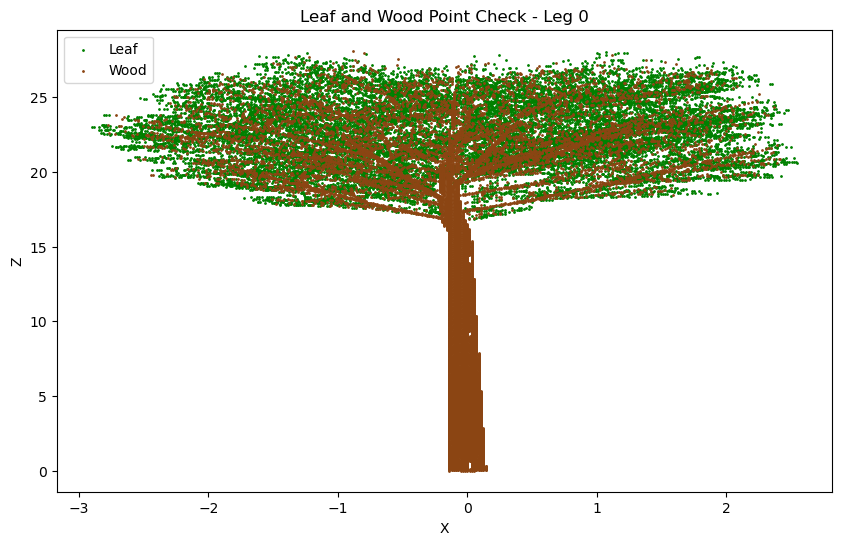

Saving leaf and wood point clouds...
Helios data preparation complete.


<Figure size 640x480 with 0 Axes>

In [22]:
from utils import prepare_helios_data

# Run the data preparation script
prepare_helios_data(
    input_dir=helios_dir, 
    output_dir=valid_rays_dir, 
    references_dir=references_dir, 
    leaf_object_ids=leaf_object_ids, 
    wood_object_ids=wood_object_ids, 
    use_class=use_class,
    debug=True
)

### Step 1.5 -  Compute Normals and Weights for Leaf Points

In [23]:
from utils import add_normals_weights_to_valid_rays

# Calculate normals and weights by loading valid rays
add_normals_weights_to_valid_rays(
    valid_rays_dir, 
    debug=True,
    knn=6
)

Loading 12 files...

[                                        ] | 0% Completed | 236.72 us


[                                        ] | 0% Completed | 101.64 ms


[                                        ] | 0% Completed | 202.61 ms


[                                        ] | 0% Completed | 303.74 ms


[                                        ] | 0% Completed | 404.73 ms

...

Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_erectophile/valid_rays/leg_7_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_erectophile/valid_rays/leg_8_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_erectophile/valid_rays/leg_9_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_erectophile/valid_rays/leg_10_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_erectophile/valid_rays/leg_11_valid_rays.parquet
Saved 12 valid rays files with normals and weights.


## Step 2 - Voxel Ray Intersections
This code uses the valid rays from before, alongside the reference datasets in order to create a supporting parquet in the valid rays folder using the voxel_size_{voxel_size}_leg_{leg}_intersections.parquet format.

In [24]:
from utils import voxel_ray_intersections

# Run intersections
voxel_ray_intersections(
    valid_rays_dir=valid_rays_dir, 
    references_dir=references_dir,
    debug=False
)

[voxel_ray_intersections] Initialising Dask client...
Detected SLURM_CPUS_PER_TASK=96
Using HPC temporary directory: /scratch/temp/19786452
[voxel_ray_intersections] Starting Dask with memory_limit=12500MB


Found 4 voxel reference files.


Compiled voxel references with 19087 entries.
Found 12 valid rays files.
[voxel_ray_intersections] Loading valid rays file for leg 0: /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_erectophile/valid_rays/leg_0_valid_rays.parquet
[voxel_ray_intersections] Leg 0 partitions: 6
[voxel_ray_intersections] Mapped partitions for leg 0
[voxel_ray_intersections] Loading valid rays file for leg 3: /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_erectophile/valid_rays/leg_3_valid_rays.parquet
[voxel_ray_intersections] Leg 3 partitions: 6
[voxel_ray_intersections] Mapped partitions for leg 3
[voxel_ray_intersections] Loading valid rays file for leg 2: /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_erectophile/valid_rays/leg_2_valid_rays.parquet
[voxel_ray_intersections] Leg 2 partitions: 6
[voxel_ray_intersections] Mapped partitions for leg 2
[voxel_ray_intersections] Loading valid rays file for leg 1: /scratch/project/veg3d/uqrarya1/code/PlantDensi

[voxel_ray_intersections] Leg 3 grouped into 4 voxel_size groups.


[voxel_ray_intersections] Saving group voxel_size=0.2 (rows=803411) for leg 3


...

2026-01-16 16:31:31,080 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:34493' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-27e9ca351e2668121b4cc6e0182cb315', 0)} (stimulus_id='handle-worker-cleanup-1768545091.080586')


2026-01-16 16:31:31,081 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:37681' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-51da9c733a2a96f136f8edf498de181b', 0)} (stimulus_id='handle-worker-cleanup-1768545091.0816343')


2026-01-16 16:31:31,083 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:37885' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-bf79a40853782a4d12ce097ed2f0b57c', 0)} (stimulus_id='handle-worker-cleanup-1768545091.0832665')


2026-01-16 16:31:31,084 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:34633' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-e0da6a8bccdb89e06e79e803d2118ac3', 0)} (stimulus_id='handle-worker-cleanup-1768545091.084106')


Deleted Dask worker scratch space at /scratch/temp/19786452/dask-scratch-space
[voxel_ray_intersections] Dask client closed.


## Step 3 - Compute Metrics
Using the leg_{leg_id}_voxel_size_{voxel_size}_intersections.parquet files (which feature a standardised structure of columns from various inputs), compute the desired metrics and save outputs.

In [25]:
import os
import glob
import utils
import pandas as pd
from utils import calculate_lambda_1, get_voxel_metrics

# Select the desired legs and voxel_sizes to include in the analysis
# Use the shortcut string 'all' to include all 
legs = 'all' # [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] 
voxel_sizes = 'all' #'all' # [0.2, 0.5, 1.0, 2.0]

leg_string = None if not legs == 'all' else legs

# Set the average leaf area
average_leaf_area = 0.0018803000643493  # in m^2, adjust as needed

# Get the list of all voxel sizes
intersection_files = []
if legs == 'all' and voxel_sizes == 'all':
    intersection_files = glob.glob(os.path.join(valid_rays_dir, '*_intersections.parquet'))
elif legs == 'all' and isinstance(voxel_sizes, list):
    for voxel_size in voxel_sizes:
        intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_*_voxel_{voxel_size}_intersections.parquet'))
elif isinstance(legs, list) and voxel_sizes == 'all':
    for leg in legs:
        intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_{leg}_*_intersections.parquet'))
else:
    for leg in legs:
        for voxel_size in voxel_sizes:
            intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_{leg}_voxel_{voxel_size}_intersections.parquet'))

# Check if any intersection files were found
if intersection_files == []:
    print("No intersection files found. Please check the input parameters.")

# Split intersection files into separate lists for each voxel_size
voxel_size_files = {}
for file in intersection_files:
    # Extract the voxel size from the filename
    parts = file.split('_')
    voxel_size = float(parts[parts.index('voxel') + 1])
    
    # Add the file to the corresponding voxel size list
    if voxel_size not in voxel_size_files:
        voxel_size_files[voxel_size] = []
    voxel_size_files[voxel_size].append(file)

# Extract voxel information for each voxel size
for voxel_size, files in voxel_size_files.items():
    # Create a list of all legs in files
    legs = []
    for file in files:
        leg = os.path.basename(file)
        parts = leg.split('_')
        leg = int(parts[parts.index('leg') + 1])
        legs.append(leg)

    # Calculate the lambda_1 for average leaf area
    lambda_1 = calculate_lambda_1(voxel_size=voxel_size, average_leaf_area=average_leaf_area)
    print(f"Voxel size: {voxel_size}, Lambda_1: {lambda_1}")

    # Calculate per voxel information from all files
    voxel_metrics_df = get_voxel_metrics(
        intersections_files=files, 
        lambda_1=lambda_1,
        is_multireturn=False
    )

    # Retrieve the reference file
    reference_file = glob.glob(os.path.join(references_dir, f'*{voxel_size}*'))[0]
    df_ref = pd.read_csv(reference_file)

    # CI_leaf_Corr, CI_lw_Corr
    # Ensure only numeric columns are included in the mean operation
    if 'voxel_id' in df_ref.columns:
        df_ref = df_ref.groupby('voxel_id').mean(numeric_only=True).reset_index()
        df_ref = df_ref.add_suffix('_ref')
    elif 'voxel_cx' in df_ref.columns:
        df_ref = df_ref.groupby(['voxel_cx', 'voxel_cy', 'voxel_cz']).mean(numeric_only=True).reset_index()
        df_ref = df_ref.add_suffix('_ref')

    df_ref.rename(columns={
        'voxel_id_ref': 'voxel_id',
        'LAD_ref_ref': 'LAD_ref', 
        'PAD_ref_ref': 'PAD_ref'
        }, inplace=True)

    for c in ['voxel_cx' ,'voxel_cy', 'voxel_cz']:
        if c + '_ref' in df_ref.columns:
            df_ref.rename(columns={c + '_ref': c}, inplace=True)

    # Merge to maintain voxel_id matching
    if 'voxel_id' in df_ref.columns:
        voxel_metrics_df = voxel_metrics_df.merge(df_ref, on='voxel_id', how='left')

        if 'voxel_cx' in voxel_metrics_df.columns:
            voxel_metrics_df.drop(columns=['voxel_cx'], inplace=True)
        if 'voxel_cy' in voxel_metrics_df.columns:
            voxel_metrics_df.drop(columns=['voxel_cy'], inplace=True)
        if 'voxel_cz' in voxel_metrics_df.columns:
            voxel_metrics_df.drop(columns=['voxel_cz'], inplace=True)
            
    elif 'voxel_cx' in df_ref.columns:
        voxel_metrics_df = voxel_metrics_df.merge(df_ref, on=['voxel_cx', 'voxel_cy', 'voxel_cz'], how='left')
    

    ### Add LAD calculations here if desired
    """Example, LAD_BL_TLS

    # Retrieve required variables
    I_leaf = voxel_metrics_df['I_leaf'].values
    mean_path_length = voxel_metrics_df['mean_path_length'].values  
    G_leaf = voxel_metrics_df['G_leaf'].values
    CI_leaf_ref = voxel_metrics_df['CI_leaf_corr_ref'].values

    LAD_BL_TLS = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length)
    LAD_BL_TLS_G = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length, G=G_leaf)
    LAD_BL_TLS_CI_ref = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length, G=G_leaf, CI=CI_leaf_ref)
    """

    # Save outputs to csv
    project_name = os.path.basename(os.path.normpath(project_dir))
    if leg_string is None:
        legs.sort()
        leg_string = "_".join(map(str, legs))
    output_file = os.path.join(results_dir, f"{project_name}_leg_{leg_string}_voxel_size_{voxel_size}.csv")
    if os.path.exists(output_file):
        os.remove(output_file)
    voxel_metrics_df.to_csv(output_file)

Voxel size: 2.0, Lambda_1: 0.0002350375080436625


2026-01-16 16:31:36,090 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle b56ba1f3f66be671b333fcebeb90e504 initialized by task ('shuffle-transfer-b56ba1f3f66be671b333fcebeb90e504', 0) executed on worker tcp://127.0.0.1:40687


2026-01-16 16:31:37,767 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle b56ba1f3f66be671b333fcebeb90e504 deactivated due to stimulus 'task-finished-1768545097.7664437'


2026-01-16 16:31:38,759 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:38817' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-c94cb7f2646a4134d26d3f7c7c5b5565', 0)} (stimulus_id='handle-worker-cleanup-1768545098.7596204')


Deleted Dask worker scratch space at /scratch/temp/19786452/dask-scratch-space
Voxel size: 1.0, Lambda_1: 0.0018803000643493


...

2026-01-16 16:32:00,232 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 09019426057975d2909b92ed12c72ca5 initialized by task ('shuffle-transfer-09019426057975d2909b92ed12c72ca5', 0) executed on worker tcp://127.0.0.1:33437


2026-01-16 16:32:02,092 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 09019426057975d2909b92ed12c72ca5 deactivated due to stimulus 'task-finished-1768545122.0661'


2026-01-16 16:32:17,778 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:35399' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-92427531b10e45b4c47aa6f2fb986ac9', 0)} (stimulus_id='handle-worker-cleanup-1768545137.7779186')


Voxel 594581022 has no rays.


Deleted Dask worker scratch space at /scratch/temp/19786452/dask-scratch-space


# Analyse Helios Simulations
This notebook walks through the process of analysing helios simulations which follows 3 main steps:

    (1) Data Preparation
        This stage will setup the project directory, setup expected schemas for dataframes (both dask and pandas), and ultimately read in the helios data and prepare the required per ray information into a .parquet output.
        It will also setup the reference dataset for voxels for each voxel_size in the project (i.e. unique voxel_ids etc.).
    
    (2) Voxel-Ray Intersection
        With valid rays saved per leg of the scan, in the previous step, the goal now is to check ray intersections in all voxels. This will record important information, such as the entry/exit/hit coordinates of the ray which will later be used to gather metrics.
        The main reason these metrics are not gathered yet, is that this stage will remain separate per leg. That way, the metrics can be computed from different combinations of helios legs without re-computing voxel-ray intersections.

    (3) Compute Metrics
        Taking a given set of legs and voxel_sizes, the voxel_ray intersection files will be used to calculate metrics for each voxel, in this case resulting in all outputs from each investigated method.

# Step 1 - Setup Project
Set project paths here

In [26]:
import os

# Set up the project directory
project_dir = '/scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_extremophile'
helios_dir = os.path.join(project_dir, 'helios')
references_dir = os.path.join(project_dir, 'references')
results_dir = os.path.join(project_dir, 'results')
valid_rays_dir = os.path.join(project_dir, 'valid_rays')

if not os.path.exists(helios_dir) or not os.path.exists(references_dir):
    raise FileNotFoundError("The specified directories do not exist. Please check the paths.")

if not os.path.exists(valid_rays_dir):
    os.makedirs(valid_rays_dir, exist_ok=True)

if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)

use_class = True
leaf_object_ids = [1]
wood_object_ids = [0]


## Step 1 - Data Preparation
This step focuses on converting helios simulation outputs, saving only valid rays into a more efficient .parquet file format.

It expects the following input and will add a new folder (valid_rays) to store all resulting .parquet files.

INPUT:
    project_dir/
    ├── reference/
    │   ├── "{project}_voxel_size_0.2.csv"
    │   ├── "{project}_voxel_size_0.5.csv"
    │   ...
    │   └── "{project}_voxel_size_{v}.csv"
    ├── helios/
    │   ├── "leg000_points.xyz"
    │   ├── "leg000_pulse.txt"
    │   ├── "leg000_fullwave.txt"
    │   ├── "leg001_points.xyz"
    │   ├── "leg001_pulse.txt"
    │   ├── "leg001_fullwave.txt"
    │   ├── ...
    │   ├── "leg{l}_points.xyz"
    │   ├── "leg{l}_pulse.txt"
    │   └── "leg{l}_fullwave.txt"

OUTPUT:
    └── valid_rays/
        ├── "leg_000_valid_rays.parquet"
        ├── "leg_001_valid_rays.parquet"
        ...
        └── "leg_{l}_valid_rays.parquet"

Processing dask delayed functions...

[                                        ] | 0% Completed | 196.57 us


[                                        ] | 0% Completed | 103.44 ms


[########################################] | 100% Completed | 208.14 ms

Processing leg 0...

[                                        ] | 0% Completed | 234.69 us


[##                                      ] | 5% Completed | 110.59 ms

...


[#####################################   ] | 94% Completed | 1.01 s


[######################################  ] | 97% Completed | 1.11 s


[########################################] | 100% Completed | 1.21 s

Debugging output...
Total Helios points 305213 do not match total valid points 305167


Total Helios rays 80956648 match total valid rays 80956648
Plotting leaf and wood points to check classification...


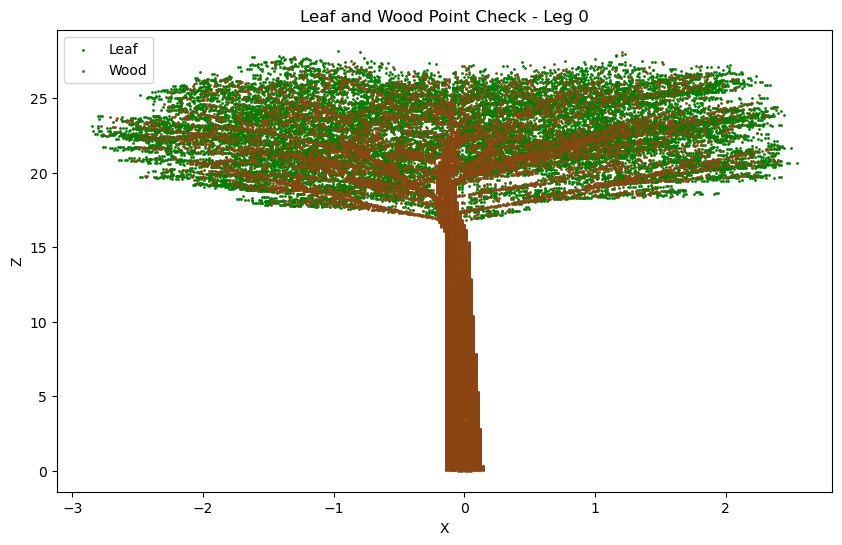

Saving leaf and wood point clouds...
Helios data preparation complete.


<Figure size 640x480 with 0 Axes>

In [27]:
from utils import prepare_helios_data

# Run the data preparation script
prepare_helios_data(
    input_dir=helios_dir, 
    output_dir=valid_rays_dir, 
    references_dir=references_dir, 
    leaf_object_ids=leaf_object_ids, 
    wood_object_ids=wood_object_ids, 
    use_class=use_class,
    debug=True
)

### Step 1.5 -  Compute Normals and Weights for Leaf Points

In [28]:
from utils import add_normals_weights_to_valid_rays

# Calculate normals and weights by loading valid rays
add_normals_weights_to_valid_rays(
    valid_rays_dir, 
    debug=True,
    knn=6
)

Loading 12 files...

[                                        ] | 0% Completed | 190.44 us


[                                        ] | 0% Completed | 101.54 ms


[                                        ] | 0% Completed | 202.28 ms


[                                        ] | 0% Completed | 303.27 ms


[                                        ] | 0% Completed | 404.12 ms

...

Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_extremophile/valid_rays/leg_7_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_extremophile/valid_rays/leg_8_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_extremophile/valid_rays/leg_9_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_extremophile/valid_rays/leg_10_valid_rays.parquet


Saved /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_extremophile/valid_rays/leg_11_valid_rays.parquet
Saved 12 valid rays files with normals and weights.


## Step 2 - Voxel Ray Intersections
This code uses the valid rays from before, alongside the reference datasets in order to create a supporting parquet in the valid rays folder using the voxel_size_{voxel_size}_leg_{leg}_intersections.parquet format.

In [29]:
from utils import voxel_ray_intersections

# Run intersections
voxel_ray_intersections(
    valid_rays_dir=valid_rays_dir, 
    references_dir=references_dir,
    debug=False
)

[voxel_ray_intersections] Initialising Dask client...
Detected SLURM_CPUS_PER_TASK=96
Using HPC temporary directory: /scratch/temp/19786452
[voxel_ray_intersections] Starting Dask with memory_limit=12500MB


Found 4 voxel reference files.


Compiled voxel references with 19066 entries.
Found 12 valid rays files.
[voxel_ray_intersections] Loading valid rays file for leg 0: /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_extremophile/valid_rays/leg_0_valid_rays.parquet
[voxel_ray_intersections] Leg 0 partitions: 6
[voxel_ray_intersections] Mapped partitions for leg 0
[voxel_ray_intersections] Loading valid rays file for leg 3: /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_extremophile/valid_rays/leg_3_valid_rays.parquet
[voxel_ray_intersections] Leg 3 partitions: 6
[voxel_ray_intersections] Mapped partitions for leg 3
[voxel_ray_intersections] Loading valid rays file for leg 2: /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_extremophile/valid_rays/leg_2_valid_rays.parquet
[voxel_ray_intersections] Leg 2 partitions: 6
[voxel_ray_intersections] Mapped partitions for leg 2
[voxel_ray_intersections] Loading valid rays file for leg 1: /scratch/project/veg3d/uqrarya1/code/PlantDe

[voxel_ray_intersections] Leg 6 grouped into 4 voxel_size groups.
[voxel_ray_intersections] Saving group voxel_size=0.2 (rows=353410) for leg 6


Saved intersections for leg_id: 6 to /scratch/project/veg3d/uqrarya1/code/PlantDensityAnalysis/POTR2_extremophile/valid_rays/leg_6_voxel_0.2_intersections.parquet.
[voxel_ray_intersections] Saving group voxel_size=0.5 (rows=330921) for leg 6


...

2026-01-16 17:31:07,516 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:36381' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-f0e7c02465a3c4c8e0758b28dcd6c3bd', 0)} (stimulus_id='handle-worker-cleanup-1768548667.5168073')


2026-01-16 17:31:07,519 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:34725' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-68de8e095c9a016dff13f1d634a0a1d9', 0)} (stimulus_id='handle-worker-cleanup-1768548667.518995')


2026-01-16 17:31:07,520 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:41759' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-b01e118e3339afda1d2f6b5d5078bef1', 0)} (stimulus_id='handle-worker-cleanup-1768548667.5202136')


[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1503488
  - Optimal chunk size: 55 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1503488
  - Optimal chunk size: 55 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1048576
  - Optimal chunk size: 79 voxels
[traverse_voxels] Memory diagnostics:
  - Number of unique rays (U): 1503488
  - Optimal chunk size: 55 voxels
[

Deleted Dask worker scratch space at /scratch/temp/19786452/dask-scratch-space
[voxel_ray_intersections] Dask client closed.


## Step 3 - Compute Metrics
Using the leg_{leg_id}_voxel_size_{voxel_size}_intersections.parquet files (which feature a standardised structure of columns from various inputs), compute the desired metrics and save outputs.

In [30]:
import os
import glob
import utils
import pandas as pd
from utils import calculate_lambda_1, get_voxel_metrics

# Select the desired legs and voxel_sizes to include in the analysis
# Use the shortcut string 'all' to include all 
legs = 'all' # [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] 
voxel_sizes = 'all' #'all' # [0.2, 0.5, 1.0, 2.0]

leg_string = None if not legs == 'all' else legs

# Set the average leaf area
average_leaf_area = 0.0018803000643493  # in m^2, adjust as needed

# Get the list of all voxel sizes
intersection_files = []
if legs == 'all' and voxel_sizes == 'all':
    intersection_files = glob.glob(os.path.join(valid_rays_dir, '*_intersections.parquet'))
elif legs == 'all' and isinstance(voxel_sizes, list):
    for voxel_size in voxel_sizes:
        intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_*_voxel_{voxel_size}_intersections.parquet'))
elif isinstance(legs, list) and voxel_sizes == 'all':
    for leg in legs:
        intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_{leg}_*_intersections.parquet'))
else:
    for leg in legs:
        for voxel_size in voxel_sizes:
            intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_{leg}_voxel_{voxel_size}_intersections.parquet'))

# Check if any intersection files were found
if intersection_files == []:
    print("No intersection files found. Please check the input parameters.")

# Split intersection files into separate lists for each voxel_size
voxel_size_files = {}
for file in intersection_files:
    # Extract the voxel size from the filename
    parts = file.split('_')
    voxel_size = float(parts[parts.index('voxel') + 1])
    
    # Add the file to the corresponding voxel size list
    if voxel_size not in voxel_size_files:
        voxel_size_files[voxel_size] = []
    voxel_size_files[voxel_size].append(file)

# Extract voxel information for each voxel size
for voxel_size, files in voxel_size_files.items():
    # Create a list of all legs in files
    legs = []
    for file in files:
        leg = os.path.basename(file)
        parts = leg.split('_')
        leg = int(parts[parts.index('leg') + 1])
        legs.append(leg)

    # Calculate the lambda_1 for average leaf area
    lambda_1 = calculate_lambda_1(voxel_size=voxel_size, average_leaf_area=average_leaf_area)
    print(f"Voxel size: {voxel_size}, Lambda_1: {lambda_1}")

    # Calculate per voxel information from all files
    voxel_metrics_df = get_voxel_metrics(
        intersections_files=files, 
        lambda_1=lambda_1,
        is_multireturn=False
    )

    # Retrieve the reference file
    reference_file = glob.glob(os.path.join(references_dir, f'*{voxel_size}*'))[0]
    df_ref = pd.read_csv(reference_file)

    # CI_leaf_Corr, CI_lw_Corr
    # Ensure only numeric columns are included in the mean operation
    if 'voxel_id' in df_ref.columns:
        df_ref = df_ref.groupby('voxel_id').mean(numeric_only=True).reset_index()
        df_ref = df_ref.add_suffix('_ref')
    elif 'voxel_cx' in df_ref.columns:
        df_ref = df_ref.groupby(['voxel_cx', 'voxel_cy', 'voxel_cz']).mean(numeric_only=True).reset_index()
        df_ref = df_ref.add_suffix('_ref')

    df_ref.rename(columns={
        'voxel_id_ref': 'voxel_id',
        'LAD_ref_ref': 'LAD_ref', 
        'PAD_ref_ref': 'PAD_ref'
        }, inplace=True)

    for c in ['voxel_cx' ,'voxel_cy', 'voxel_cz']:
        if c + '_ref' in df_ref.columns:
            df_ref.rename(columns={c + '_ref': c}, inplace=True)

    # Merge to maintain voxel_id matching
    if 'voxel_id' in df_ref.columns:
        voxel_metrics_df = voxel_metrics_df.merge(df_ref, on='voxel_id', how='left')

        if 'voxel_cx' in voxel_metrics_df.columns:
            voxel_metrics_df.drop(columns=['voxel_cx'], inplace=True)
        if 'voxel_cy' in voxel_metrics_df.columns:
            voxel_metrics_df.drop(columns=['voxel_cy'], inplace=True)
        if 'voxel_cz' in voxel_metrics_df.columns:
            voxel_metrics_df.drop(columns=['voxel_cz'], inplace=True)
            
    elif 'voxel_cx' in df_ref.columns:
        voxel_metrics_df = voxel_metrics_df.merge(df_ref, on=['voxel_cx', 'voxel_cy', 'voxel_cz'], how='left')
    

    ### Add LAD calculations here if desired
    """Example, LAD_BL_TLS

    # Retrieve required variables
    I_leaf = voxel_metrics_df['I_leaf'].values
    mean_path_length = voxel_metrics_df['mean_path_length'].values  
    G_leaf = voxel_metrics_df['G_leaf'].values
    CI_leaf_ref = voxel_metrics_df['CI_leaf_corr_ref'].values

    LAD_BL_TLS = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length)
    LAD_BL_TLS_G = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length, G=G_leaf)
    LAD_BL_TLS_CI_ref = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length, G=G_leaf, CI=CI_leaf_ref)
    """

    # Save outputs to csv
    project_name = os.path.basename(os.path.normpath(project_dir))
    if leg_string is None:
        legs.sort()
        leg_string = "_".join(map(str, legs))
    output_file = os.path.join(results_dir, f"{project_name}_leg_{leg_string}_voxel_size_{voxel_size}.csv")
    if os.path.exists(output_file):
        os.remove(output_file)
    voxel_metrics_df.to_csv(output_file)

Voxel size: 2.0, Lambda_1: 0.0002350375080436625


2026-01-16 17:31:12,959 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle e0576e0fc3d6fbb80bdf27d52df6e8a7 initialized by task ('shuffle-transfer-e0576e0fc3d6fbb80bdf27d52df6e8a7', 9) executed on worker tcp://127.0.0.1:38763


2026-01-16 17:31:14,825 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle e0576e0fc3d6fbb80bdf27d52df6e8a7 deactivated due to stimulus 'task-finished-1768548674.8209476'


2026-01-16 17:31:15,787 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/home/uqrarya1/miniconda3/envs/plantdensityanalysis_env/lib/python3.13/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/uqrarya1/miniconda3/envs/plantdensityanalysis_env/lib/python3.13/site-packages/distributed/worker.py", line 1267, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
    ...<14 lines>...
    )
    ^
  File "/home/uqrarya1/miniconda3/envs/plantdensityanalysis_env/lib/python3.13/site-packages/distributed/utils_comm.py", line 416, in retry_operation
    return await retry(
   

Deleted Dask worker scratch space at /scratch/temp/19786452/dask-scratch-space
Voxel size: 1.0, Lambda_1: 0.0018803000643493


...

2026-01-16 17:31:40,351 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle b78fda9bb3f66926a9bbcd5d03be3837 initialized by task ('shuffle-transfer-b78fda9bb3f66926a9bbcd5d03be3837', 9) executed on worker tcp://127.0.0.1:33823


2026-01-16 17:31:41,916 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle b78fda9bb3f66926a9bbcd5d03be3837 deactivated due to stimulus 'task-finished-1768548701.9153173'


2026-01-16 17:31:54,940 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:35847' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('repartitiontofewer-278efc773359ed10e55ad0d9690c87d1', 0)} (stimulus_id='handle-worker-cleanup-1768548714.9403365')


Voxel 3236823756 has no rays.
Voxel 168720357 has no rays.
Voxel 1957530016 has no rays.
Voxel 2540684982 has no rays.
Voxel 1253466093 has no rays.
Voxel 294630375 has no rays.
Voxel 2891502306 has no rays.


Deleted Dask worker scratch space at /scratch/temp/19786452/dask-scratch-space
